In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [14]:
# Read dataset
df = pd.read_csv("credit_data.csv")
print("Dataset:")
print(df)

Dataset:
    Age  Income     Education  Employment  LoanAmount  CreditScore Property  \
0    22   20000      Graduate  Unemployed       50000          580       No   
1    25   25000      Graduate    Employed       60000          600       No   
2    28   30000      Graduate    Employed       80000          620       No   
3    30   35000  Postgraduate    Employed      100000          650      Yes   
4    32   40000  Postgraduate    Employed      120000          670      Yes   
5    35   45000  Postgraduate    Employed      150000          700      Yes   
6    38   50000      Graduate    Employed      140000          690      Yes   
7    40   55000  Postgraduate    Employed      180000          720      Yes   
8    42   60000  Postgraduate    Employed      200000          750      Yes   
9    45   65000  Postgraduate    Employed      220000          760      Yes   
10   48   70000      Graduate    Employed      250000          780      Yes   
11   50   75000  Postgraduate    Employed  

In [15]:
# Convert categorical columns into numerical columns
df = pd.get_dummies(
    df,
    columns=['Education', 'Employment', 'Property'],
    drop_first=True
)
print("\nEncoded Dataset:")
print(df)


Encoded Dataset:
    Age  Income  LoanAmount  CreditScore  Credit  Education_Postgraduate  \
0    22   20000       50000          580       0                   False   
1    25   25000       60000          600       0                   False   
2    28   30000       80000          620       0                   False   
3    30   35000      100000          650       1                    True   
4    32   40000      120000          670       1                    True   
5    35   45000      150000          700       1                    True   
6    38   50000      140000          690       1                   False   
7    40   55000      180000          720       1                    True   
8    42   60000      200000          750       1                    True   
9    45   65000      220000          760       1                    True   
10   48   70000      250000          780       1                   False   
11   50   75000      270000          800       1                    Tr

In [16]:
# Separate input and output
X = df.drop('Credit', axis=1)
y = df['Credit']
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
# Create Decision Tree
model = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

In [18]:
# Train model
model.fit(X_train, y_train)
# Prediction
y_pred = model.predict(X_test)

In [19]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nTest Accuracy:", accuracy)
# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=[0, 1]))


Test Accuracy: 1.0

Confusion Matrix:
[[0 0]
 [0 6]]


In [20]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         6

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



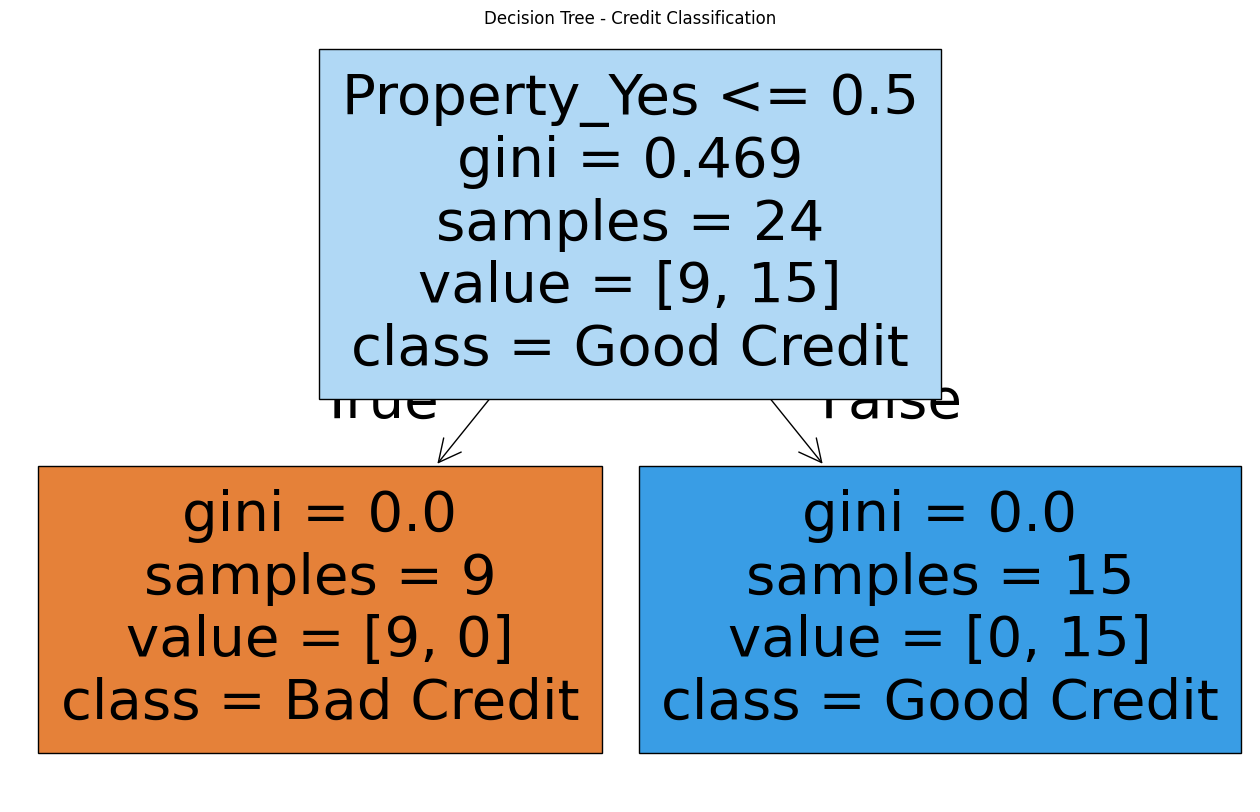

In [21]:
# Display Decision Tree
plt.figure(figsize=(16, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Bad Credit', 'Good Credit'],
    filled=True
)
plt.title("Decision Tree - Credit Classification")
plt.show()